# Music Popularity Prediction using Spotify & YouTube Data

## Business Objective
To predict whether a song will become commercially successful
using streaming and engagement metrics.

This helps:
- Optimize marketing budget
- Reduce promotion risk
- Improve revenue forecasting
- Segment songs by commercial potential

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("Spotify Youtube Dataset.csv")
# Drop unnecessary columns
df = df.drop(columns=[
    'Unnamed: 0',
    'Artist',
    'Url_spotify',
    'Track',
    'Album',
    'Album_type',
    'Uri',
    'Url_youtube',
    'Title',
    'Channel',
    'Description'
])

df.head()

,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Licensed,official_video,Stream
0,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,693555221.0,6220896.0,169907.0,True,True,1.040235e+09
1,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,72011645.0,1079128.0,31003.0,True,True,3.100837e+08
2,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,215150.0,8435055.0,282142.0,7399.0,True,True,6.306347e+07
3,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,211754952.0,1788577.0,55229.0,True,True,4.346636e+08
4,0.663,0.694,10.0,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,618480958.0,6197318.0,155930.0,True,True,6.172597e+08


In [ ]:
df.isnull().sum()

,0
Danceability,2
Energy,2
Key,2
Loudness,2
Speechiness,2
Acousticness,2
Instrumentalness,2
Liveness,2
Valence,2
Tempo,2


In [ ]:
df = df.dropna()

df.isnull().sum()

,0
Danceability,0
Energy,0
Key,0
Loudness,0
Speechiness,0
Acousticness,0
Instrumentalness,0
Liveness,0
Valence,0
Tempo,0


In [ ]:
df.shape


(19549, 17)

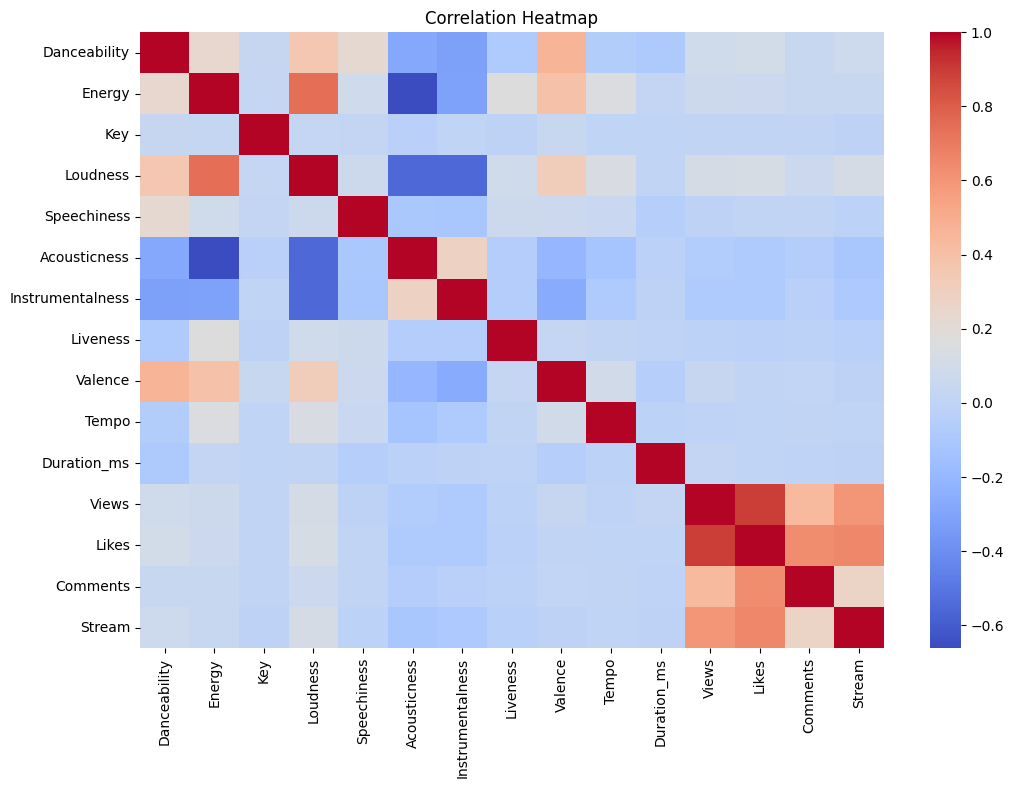

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

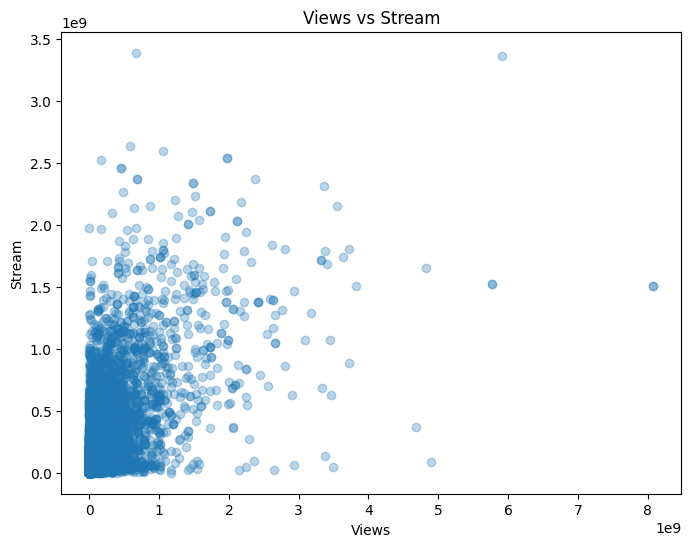

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Views'], df['Stream'], alpha=0.3)
plt.xlabel("Views")
plt.ylabel("Stream")
plt.title("Views vs Stream")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select engagement features
features = df[['Views','Likes','Comments','Danceability','Energy']]

# Scale features (VERY important for KMeans)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# See cluster averages
df.groupby('Cluster')[['Views','Likes','Stream']].mean()

,Views,Likes,Stream
Cluster,,,
0,3.925289e+07,2.856359e+05,9.434903e+07
1,6.928718e+07,4.968462e+05,1.224439e+08
2,1.269372e+09,8.555549e+06,9.000086e+08


Market Segmentation Insight

Cluster 2 represents high-engagement, high-stream tracks.
These songs have strong revenue potential and lower financial risk.
Music labels should prioritize marketing investment in this segment.

In [ ]:
df['High_Stream'] = df['Stream'].apply(
    lambda x: 1 if x > df['Stream'].median() else 0
)

df['High_Stream'].value_counts()

,count
High_Stream,
0,9776
1,9773


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['Views','Likes','Comments','Danceability','Energy',
        'Licensed','official_video']]

y = df['High_Stream']

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale AFTER splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=3000)
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.717391304347826
              precision    recall  f1-score   support

           0       0.67      0.89      0.76      1990
           1       0.83      0.54      0.65      1920

    accuracy                           0.72      3910
   macro avg       0.75      0.71      0.71      3910
weighted avg       0.74      0.72      0.71      3910



The model achieves 72% accuracy in predicting whether a song will achieve high streaming performance.

Key Insights:
	•	Engagement metrics (Views, Likes, Comments) strongly influence revenue probability.
	•	Official videos positively impact commercial success.
	•	The model helps reduce marketing risk by identifying high-probability tracks before heavy promotion investment.

This enables:
	•	Revenue optimization
	•	Demand forecasting
	•	Risk reduction
	•	Data-driven marketing allocation